# Model Evaluation

This notebook evaluates the performance of trained regression models used to predict house prices.

The objective is to analyze prediction errors, interpret feature importance, and identify the best performing model for the final solution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error,r2_score


In [2]:
ridge=joblib.load('c:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/Models/best_model.pkl')
x_test,y_test=joblib.load('c:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/Models/test_data.pkl')
pred=ridge.predict(x_test)

rmse=np.sqrt(mean_squared_error(y_test,pred))
r2=r2_score(y_test,pred)

print('Best Model: Ridge Regression')
print('RMSE:',rmse)
print('R² Score:',r2)

Best Model: Ridge Regression
RMSE: 0.12427096010206734
R² Score: 0.9022196986213613


RMSE measures the average prediction error magnitude.  
R² indicates how well the model explains the variance in house prices.

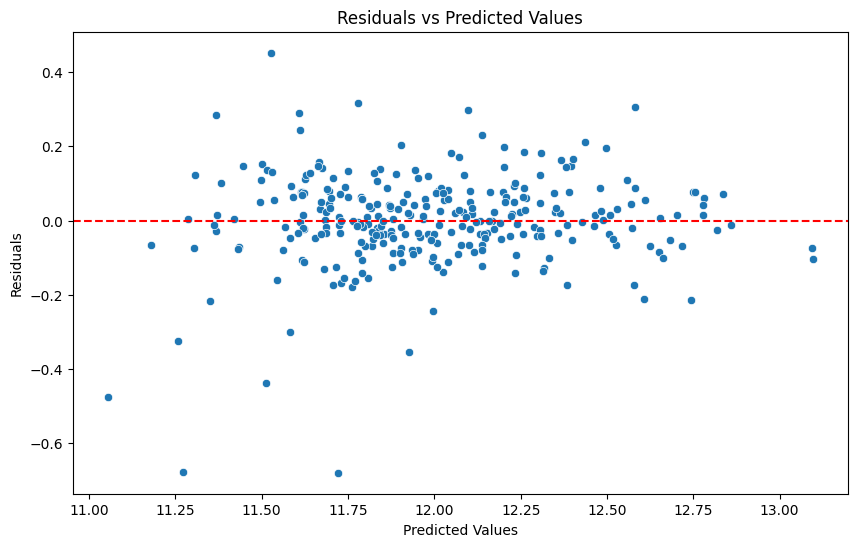

In [3]:
residuals=y_test-pred
plt.figure(figsize=(10,6))
sns.scatterplot(x=pred,y=residuals)
plt.axhline(0,color='red',linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

Residuals should be randomly distributed around zero.
Patterns in residuals may indicate model bias.

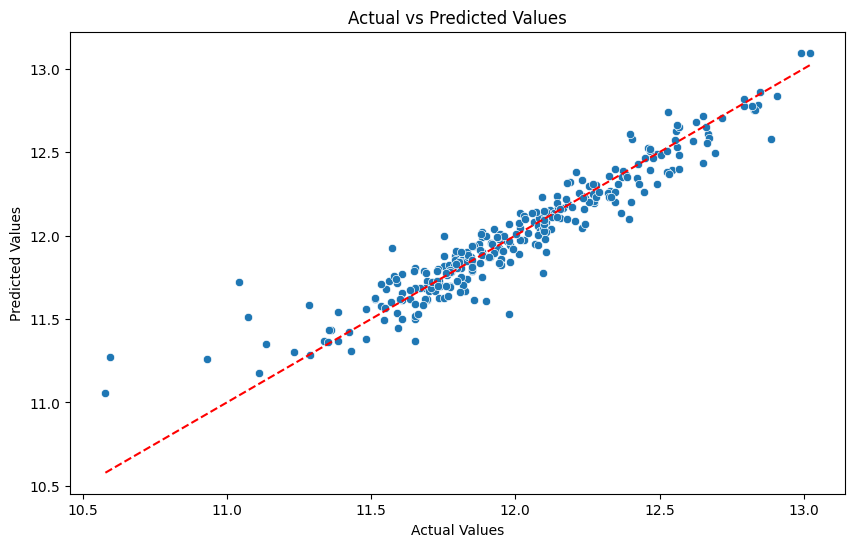

In [4]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test,y=pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='red',linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

Points close to the diagonal line indicate accurate predictions.

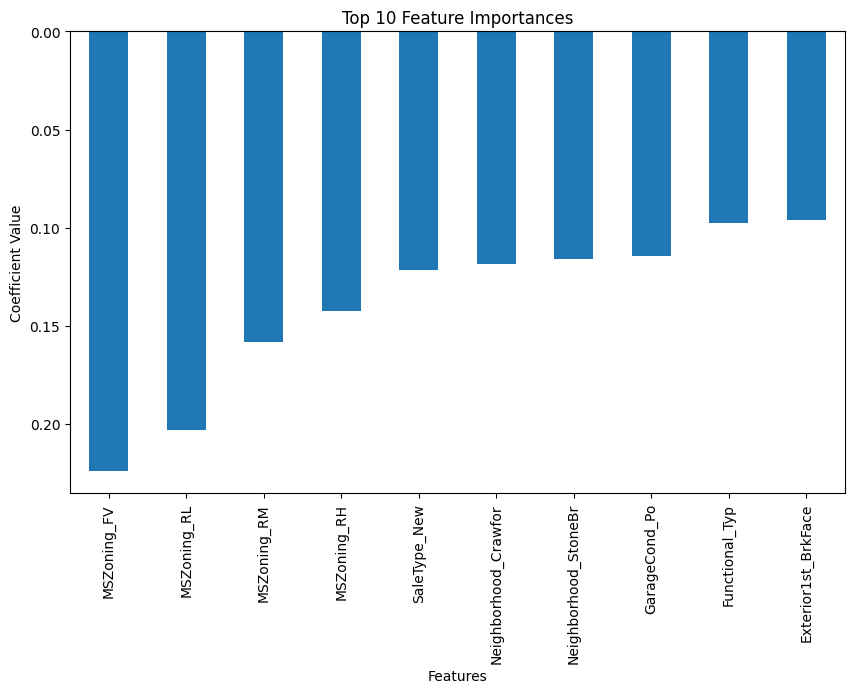

In [7]:
importances=pd.Series(ridge.coef_,index=x_test.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.show()

In [8]:
results=pd.read_csv('c:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/Models/model_comparison.csv')
results.sort_values(by='RMSE')
results.head()

,Model,RMSE
0,Linear Regression,0.130330
1,Ridge Regression,0.124271
2,Lasso Regression,0.178301
3,Random Forest,0.142699


Ridge Regression achieved the lowest RMSE, indicating the best predictive performance among the tested models.

## Final Model Selection

Based on RMSE comparison and prediction analysis, the Ridge Regression model provides the best performance for predicting house prices.

This model captures nonlinear relationships between house features and sale prices more effectively than linear models.

## Project Conclusion

This project analyzed housing data to understand the factors influencing property prices and developed predictive models for price estimation.

Key findings:
• Overall house quality strongly impacts property value.
• Larger living areas significantly increase house prices.
• Basement size and garage capacity also influence price.

Among the evaluated models, Ridge Regression achieved the best performance and was selected as the final model.